In [1]:
%load_ext autoreload
%autoreload 2
import torch
from training_functions import train, evaluate_mae_mse
from TransCrowd import base_patch16_384_token, base_patch16_384_gap
import torch.nn as nn
import torch.optim as optim
from dataloader_mcnn import CrowdDataset
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset
import glob
import os
import numpy as np
import random
import time
import pandas as pd
from torchvision import transforms
SEED = 42

e:\OneDrive\Pulpit\MSC-thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\OneDrive\Pulpit\MSC-thesis\.venv\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
e:\OneDrive\Pulpit\MSC-thesis\.venv\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [7]:
df2 = pd.read_csv(r'output\history\p2p\evaluation_extended.csv')
df2 = df2[df2['gt'] != 0]
df2['rmse'] = (df2['pred'] - df2['gt'])**2
df2.groupby('dataset').mean()

,Unnamed: 0,pred,gt,diff,abs_err,perc,rmse
dataset,,,,,,,
NWPU-Crowd,743.675269,232.929032,418.947644,-186.018612,202.843152,1.186793,490029.572111
ShanghaiTech_part_A,90.500000,259.527473,428.208765,-168.681293,178.373378,0.463076,75475.469460
ShanghaiTech_part_B,339.500000,66.158228,118.924529,-52.766302,53.209739,0.455395,4773.368863
UCF-QNRF_ECCV18,1164.500000,456.182635,713.305881,-257.123246,270.534482,0.369284,224697.330008
jhu_crowd_v2.0,2131.270050,188.186717,323.576706,-135.389989,160.483097,1.159023,211266.690596
ucf-cc-50,2956.500000,1158.380000,1272.462081,-114.082081,570.230108,0.399491,853703.385812


Text(0, 0.5, 'Difference')

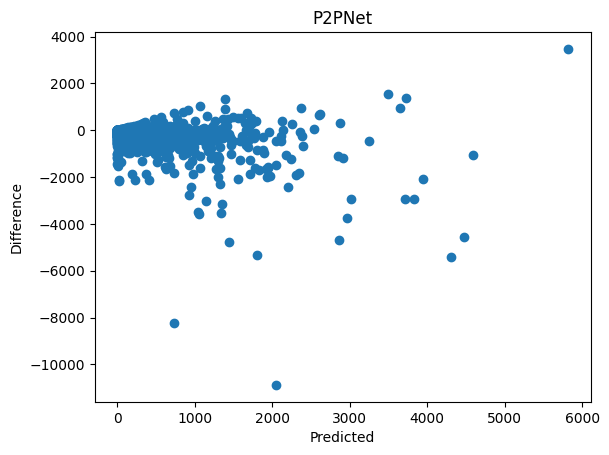

In [8]:
plt.scatter(df2['pred'], df2['diff'])
plt.title('P2PNet')
plt.xlabel('Predicted')
plt.ylabel('Difference')

Text(0, 0.5, 'Predicted')

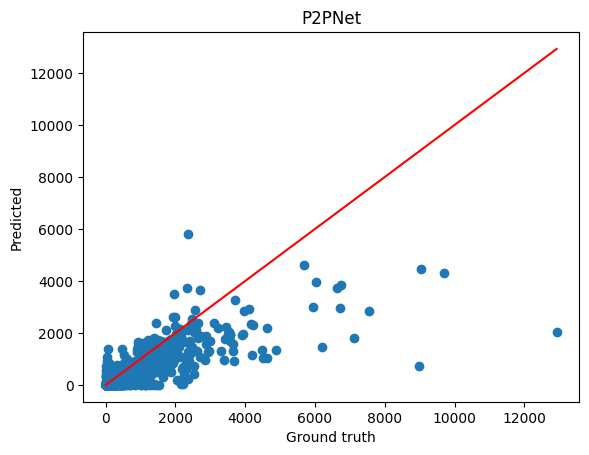

In [9]:
plt.scatter(df2['gt'], df2['pred'])
plt.plot([0,max(df2['gt'])], [0, max(df2['gt'])], color='red')
plt.title('P2PNet')
plt.xlabel('Ground truth')
plt.ylabel('Predicted')

In [2]:
df2 = pd.read_csv(r'output\history\p2p\evaluation_extended.csv')
df2 = df2[df2['gt'] == 0]


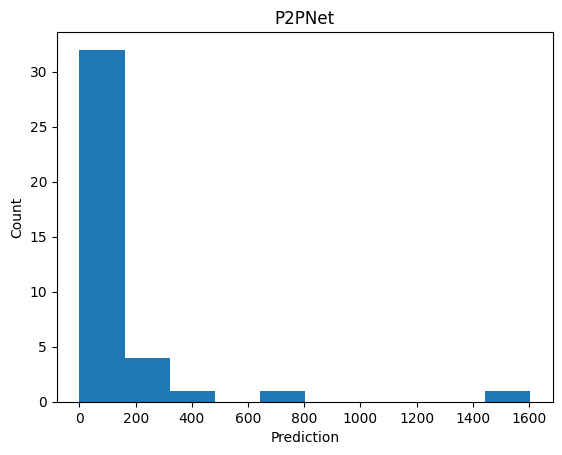

In [11]:
plt.hist(df2['pred'])
plt.xlabel("Prediction")
plt.ylabel("Count")
plt.title('P2PNet')
plt.show()

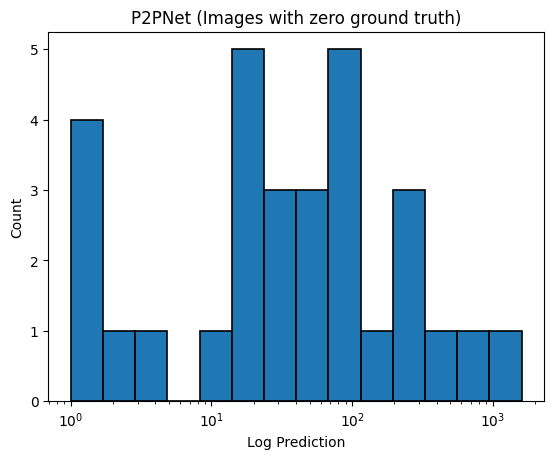

In [4]:
bins = np.logspace(
    0,
    np.log10(df2['pred'].max()),
    15
)

plt.hist(
    df2['pred'],
    bins=bins,
    edgecolor='black',
    linewidth=1.2
)

plt.xscale('log')

plt.xlabel("Log Prediction")
plt.ylabel("Count")
plt.title("P2PNet (Images with zero ground truth)")

plt.show()

In [12]:
def bins(x):
    if x <= 50:
        return 'small'
    if x <= 200:
        return 'medium'
    if x <= 1000:
        return 'high'
    else:
        return 'large'

In [13]:
df2 = pd.read_csv(r'output\history\p2p\evaluation_extended.csv')
df2 = df2[df2['gt'] != 0]
df2['bins'] = df2['gt'].apply(lambda x: bins(x))
df2['rmse'] = (df2['pred'] - df2['gt'])**2
df2.drop(columns='dataset', inplace=True)
df2 = df2.groupby(['bins']).mean()
df2['rmse'] = df2['rmse']**(1/2)
df2

,Unnamed: 0,pred,gt,diff,abs_err,perc,rmse
bins,,,,,,,
high,1376.074262,270.510682,434.608366,-164.097685,184.301662,0.440514,232.618657
large,1609.323077,1290.711538,2149.573436,-858.861898,976.080782,0.404834,1560.639453
medium,1458.670909,65.642727,114.706687,-49.063960,62.562024,0.578094,89.064870
small,1720.323333,22.296667,27.223364,-4.926697,24.722632,2.664957,68.946896
